# PSF wings: no more postage stamps

The PSF stamps are finite (129 px in focus, 257 px defocused), so without
correction the wing of every bright star is cut to exactly zero at a square
boundary. At a hard display stretch that square sits far above the noise —
~100 sigma for a G=8 star in focus at 90 s — which is the classic
"postage stamp" artifact in FITS viewers.

Since wing extension was added (`wings=True`, the default), each star's stamp is
continued beyond its edge with an analytic power-law wing fit from the stamp's
own outer annulus (`wcc_sim.wings`), on a circular footprint, down to
0.1 sigma of the sky+read noise floor. This notebook verifies the behavior and
quantifies what the wings do to the encircled energy (EE).

> **Note:** these wings describe the *diffraction* halo only. Scattered-light
> PSFs are not in the models yet; when they land, the measured extended profile
> will replace the power-law fit behind the same `WingModel` interface.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

import wcc_sim
from wcc_sim import simulate_field
from wcc_sim.detectors import make_base_simulation
from wcc_sim.psf import DEFAULT_STAMP, render_oversampled_psf
from wcc_sim.render import bin_oversampled, render_scene
from wcc_sim.wings import fit_wing_model

plt.style.use('gks')
print('wcc_sim', wcc_sim.__version__)

wcc_sim 0.1.0


## 1. Before / after on a real field

A 1024×1024 subarray centered on a G=8.1 star (Gaia DR3 3836000669773723520,
near the COSMOS field), simulated with and without wings — same seed, same
noise realization. The stretch is set just above the sky to mimic cranking the
contrast in a FITS viewer.

In [2]:
RA, DEC = 150.63121, 1.82361  # G = 8.1 star
kw = dict(sensorfilter='zwo:r', focus=0, exptime=90.0, seed=7,
          shape=(1024, 1024), cache_dir='gaia_cache')
field_off = simulate_field(RA, DEC, wings=False, **kw)
field_on = simulate_field(RA, DEC, wings=True, **kw)
star = field_on.catalog[np.argmin(field_on.catalog['phot_g_mean_mag'])]
x0, y0 = int(round(star['x'])), int(round(star['y']))
print(f"G = {star['phot_g_mean_mag']:.2f} at (x, y) = ({x0}, {y0})")
print('wing model: alpha = %.3f, c = %.4f, floor = %.3f e-/pix' % (
    field_on.params['wing_alpha'], field_on.params['wing_c'],
    field_on.params['wing_floor_e']))

G = 8.14 at (x, y) = (510, 511)
wing model: alpha = -2.996, c = 0.0766, floor = 0.328 e-/pix


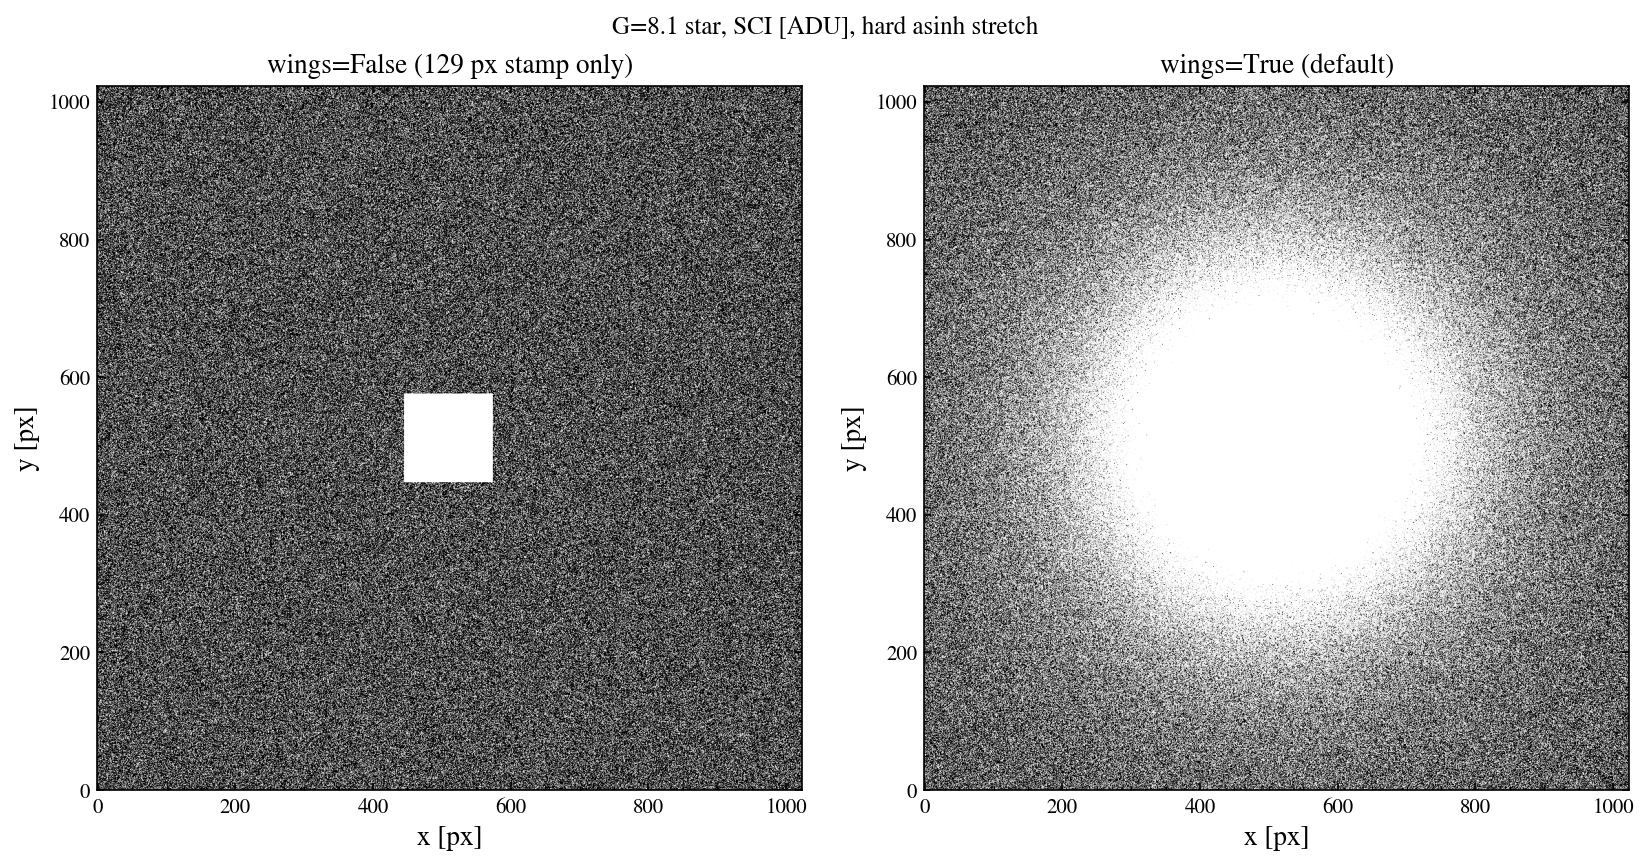

In [3]:
med = np.median(field_off.image_adu)
norm = simple_norm(field_off.image_adu, 'asinh', vmin=med - 1, vmax=med + 25)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.4), constrained_layout=True)
for ax, f, title in [(axes[0], field_off, 'wings=False (129 px stamp only)'),
                     (axes[1], field_on, 'wings=True (default)')]:
    ax.imshow(f.image_adu, origin='lower', cmap='gray', norm=norm)
    ax.set_title(title)
    ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')
    ax.grid(False)
fig.suptitle('G=8.1 star, SCI [ADU], hard asinh stretch', y=1.04);

The square is the old stamp boundary; with wings the halo is circular and fades
into the noise. A row cut through the star shows the same thing quantitatively:
the truncated profile falls off a cliff at ±64 px, the extended one follows the
r^-3 Airy envelope down to the noise.

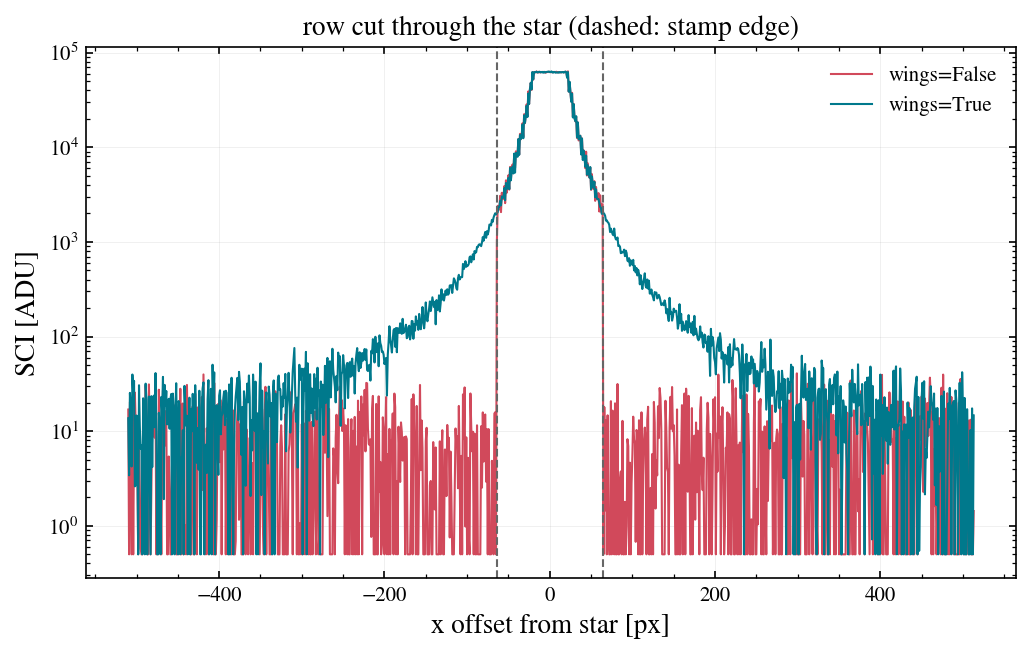

In [4]:
xs = np.arange(1024) - x0
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.semilogy(xs, np.maximum(field_off.image_adu[y0], 0.5), lw=1,
            color='#d1495b', label='wings=False')
ax.semilogy(xs, np.maximum(field_on.image_adu[y0], 0.5), lw=1,
            color='#00798c', label='wings=True')
for edge in (-64, 64):
    ax.axvline(edge, color='0.4', ls='--', lw=1)
ax.set_xlabel('x offset from star [px]'); ax.set_ylabel('SCI [ADU]')
ax.set_title('row cut through the star (dashed: stamp edge)')
ax.legend();

## 2. The wing model

`fit_wing_model` fits `profile(r) = c * r**alpha` (PSF fraction per pixel) to
the azimuthally smooth outer annulus of the detector-binned stamp. In focus the
slope comes out at the physical Airy-envelope value of −3; the defocused
Huygens PSFs fall faster.

In [5]:
sim = make_base_simulation('zwo:r')
wings, stamps = {}, {}
for focus in (0, 1, 2):
    psf_os = render_oversampled_psf(sim, focus, oversample=11)
    stamps[focus] = bin_oversampled(psf_os, 11)
    wings[focus] = fit_wing_model(stamps[focus])
    n = stamps[focus].shape[0]
    print(f'focus={focus}w  stamp={n:3d} px  '
          f'alpha={wings[focus].alpha:6.2f}  c={wings[focus].c:.3e}')

focus=0w  stamp=129 px  alpha= -3.00  c=7.663e-02


focus=1w  stamp=257 px  alpha= -3.66  c=1.257e+00


focus=2w  stamp=257 px  alpha= -4.15  c=1.543e+01


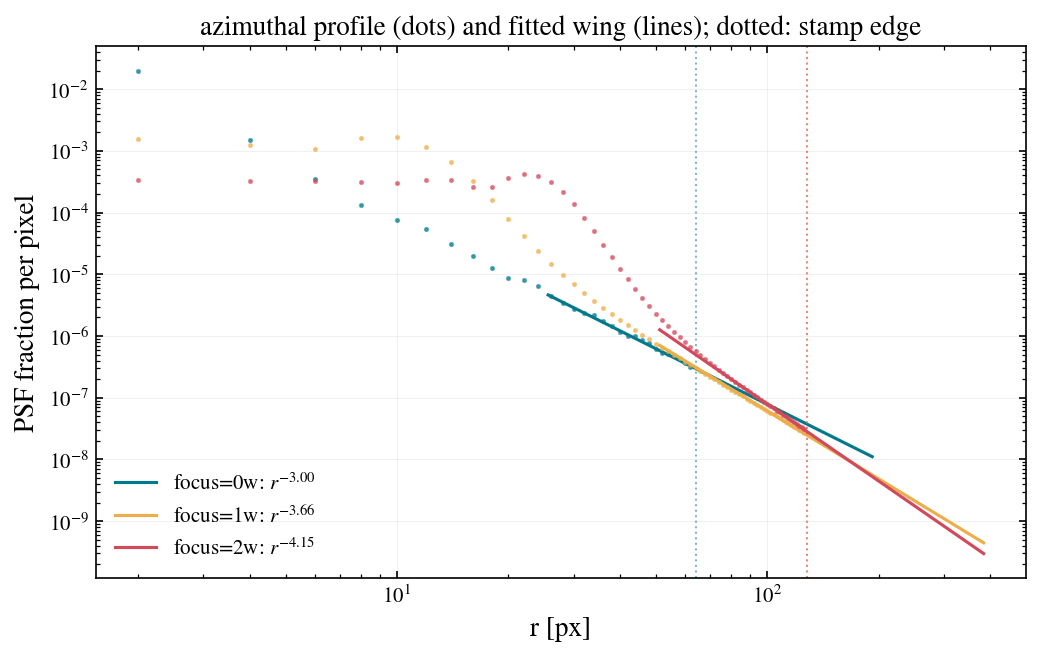

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.6))
colors = {0: '#00798c', 1: '#edae49', 2: '#d1495b'}
for focus in (0, 1, 2):
    stamp, w = stamps[focus], wings[focus]
    n = stamp.shape[0]; half = n // 2
    yy, xx = np.mgrid[:n, :n]
    r = np.hypot(yy - half, xx - half)
    rb = np.arange(2, half, 2)
    prof = [np.median(stamp[(r >= b - 1) & (r < b + 1)]) for b in rb]
    ax.loglog(rb, prof, '.', ms=3, color=colors[focus], alpha=0.6)
    rr = np.linspace(0.4 * half, 3 * half, 100)
    ax.loglog(rr, w.profile(rr), '-', color=colors[focus], lw=1.5,
              label=f'focus={focus}w: $r^{{{w.alpha:.2f}}}$')
    ax.axvline(half, color=colors[focus], ls=':', lw=1, alpha=0.5)
ax.set_xlabel('r [px]'); ax.set_ylabel('PSF fraction per pixel')
ax.set_title('azimuthal profile (dots) and fitted wing (lines); dotted: stamp edge')
ax.legend();

## 3. Seam smoothness

The fix has two parts: the stamp's outer 20% is crossfaded into the smooth
model (so Airy-ring texture doesn't stop abruptly), and the halo continues
outside on a circular footprint. On the *noiseless* image the profile should
now cross the old stamp edge without any visible jump.

In [7]:
half = 64  # 129 px in-focus stamp
row_off = field_off.image_clean[y0]
row_on = field_on.image_clean[y0]
jump_off = abs(row_off[x0 + half] - row_off[x0 + half + 2])
jump_on = abs(row_on[x0 + half] - row_on[x0 + half + 2])
local = row_on[x0 + half]
print(f'clean-image step across the stamp edge, wings off: {jump_off:9.1f} e-')
print(f'clean-image step across the stamp edge, wings on : {jump_on:9.1f} e-')
print(f'local wing level there: {local:.1f} e-/pix '
      f'-> relative jump {jump_on / local:.1%}')
assert jump_on / local < 0.15, 'seam should be smooth'
assert jump_off / local > 0.5, 'truncated case should be a cliff'

clean-image step across the stamp edge, wings off:     602.7 e-
clean-image step across the stamp edge, wings on :      48.4 e-
local wing level there: 551.2 e-/pix -> relative jump 8.8%


## 4. Encircled energy: what do the wings change?

Two effects, both small and physical:

1. **Renormalization.** The truncated stamp pretended 100% of the flux landed
   inside the stamp. With wings, every star is scaled by
   `1/(1 + E_wing)` where `E_wing` is the wing energy beyond the stamp edge —
   so EE inside any small aperture *drops* by that fraction.
2. **The halo itself.** EE keeps growing beyond the old stamp edge instead of
   flat-lining at 1.0.

Below: EE curves for a single in-focus star rendered noiselessly with and
without wings (flux 10⁹ e⁻, halo drawn to its 0.25 e⁻/pix floor at ~680 px).

In [8]:
N = 1601; c0 = N // 2; flux = 1e9
psf0 = render_oversampled_psf(sim, 0, oversample=11)
img_ee_off = render_scene((N, N), [c0], [c0], [flux], psf0, 11)
img_ee_on = render_scene((N, N), [c0], [c0], [flux], psf0, 11,
                         wing=wings[0], floor_e=0.25)
yy, xx = np.mgrid[:N, :N]
r = np.hypot(yy - c0, xx - c0).ravel()
order = np.argsort(r)
r_sorted = r[order]
ee_off = np.cumsum(img_ee_off.ravel()[order].astype(np.float64)) / flux
ee_on = np.cumsum(img_ee_on.ravel()[order].astype(np.float64)) / flux
E_wing = wings[0].energy_beyond(64.0)
print(f'total flux ratio, wings on : {img_ee_on.sum() / flux:.4f}')
print(f'total flux ratio, wings off: {img_ee_off.sum() / flux:.4f}')
print(f'analytic wing energy beyond the 129 px stamp: {E_wing:.4f} '
      f'({E_wing / (1 + E_wing):.2%} of total flux)')
assert abs(img_ee_on.sum() / flux - 1.0) < 0.01

total flux ratio, wings on : 0.9985
total flux ratio, wings off: 1.0000
analytic wing energy beyond the 129 px stamp: 0.0077 (0.76% of total flux)


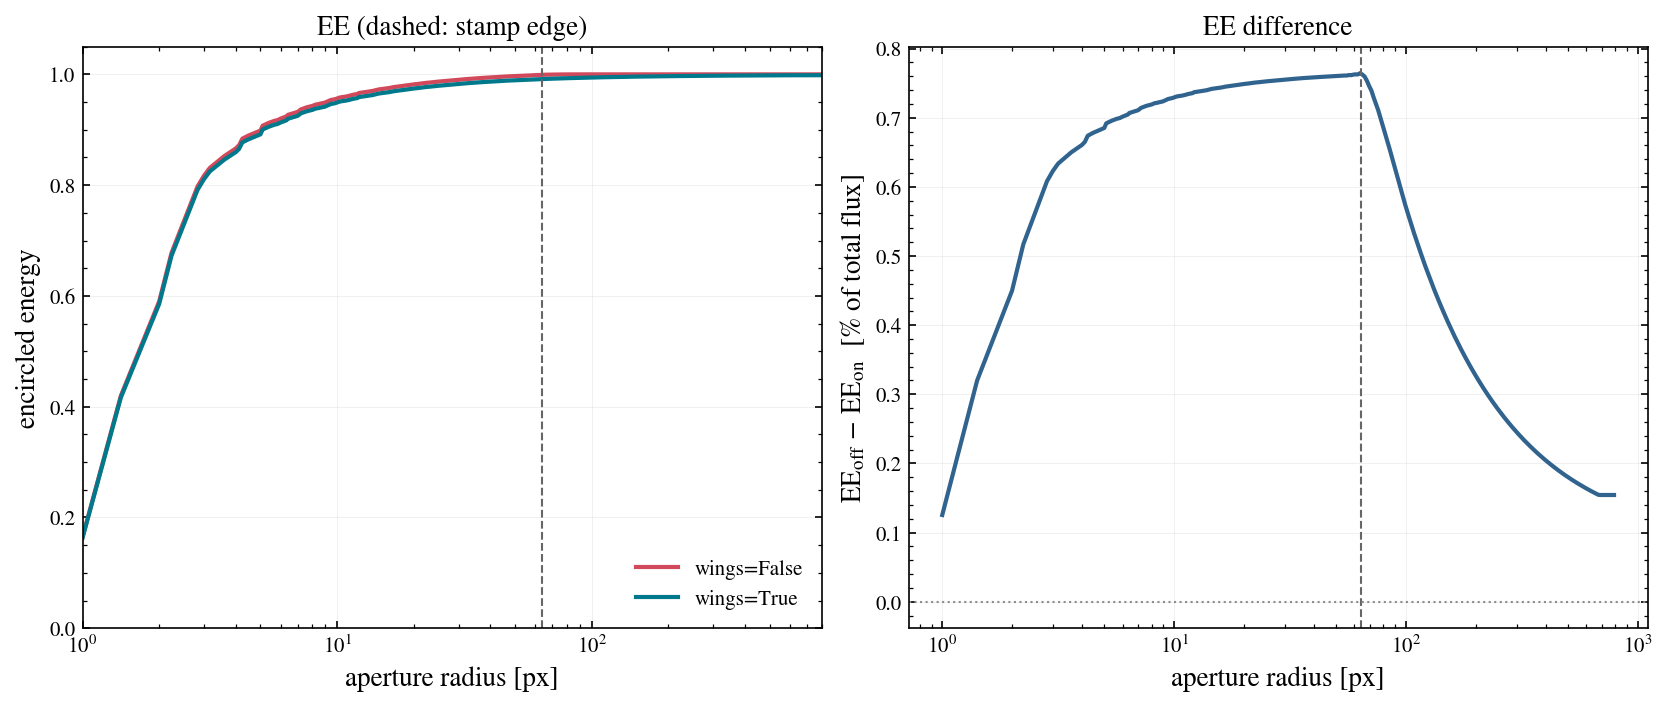

In [9]:
idx = np.unique(np.searchsorted(r_sorted, np.logspace(0, np.log10(790), 300)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
ax1.semilogx(r_sorted[idx], ee_off[idx], color='#d1495b', label='wings=False')
ax1.semilogx(r_sorted[idx], ee_on[idx], color='#00798c', label='wings=True')
ax1.axvline(64, color='0.4', ls='--', lw=1)
ax1.set_xlabel('aperture radius [px]'); ax1.set_ylabel('encircled energy')
ax1.set_xlim(1, 800); ax1.set_ylim(0, 1.05)
ax1.set_title('EE (dashed: stamp edge)')
ax1.legend(loc='lower right')

ax2.semilogx(r_sorted[idx], (ee_off - ee_on)[idx] * 100, color='#30638e')
ax2.axvline(64, color='0.4', ls='--', lw=1)
ax2.axhline(0, color='0.55', ls=':', lw=1)
ax2.set_xlabel('aperture radius [px]')
ax2.set_ylabel(r'EE$_{\rm off}$ $-$ EE$_{\rm on}$  [% of total flux]')
ax2.set_title('EE difference');

In [10]:
radii = [2, 5, 10, 20, 40, 64, 100, 200, 400, 680]
print(' r [px]   EE off    EE on    diff [%]')
for rad in radii:
    i = np.searchsorted(r_sorted, rad)
    print(f'{rad:6d}   {ee_off[i]:.4f}   {ee_on[i]:.4f}   '
          f'{(ee_off[i] - ee_on[i]) * 100:+7.3f}')
assert np.all(np.diff(ee_on[::997]) > -1e-9), 'EE must be monotonic'

 r [px]   EE off    EE on    diff [%]
     2   0.5900   0.5855    +0.450
     5   0.8986   0.8917    +0.685
    10   0.9564   0.9491    +0.729
    20   0.9820   0.9745    +0.749
    40   0.9945   0.9869    +0.758
    64   0.9992   0.9916    +0.765
   100   1.0000   0.9943    +0.571
   200   1.0000   0.9967    +0.327
   400   1.0000   0.9980    +0.205
   680   1.0000   0.9985    +0.154


Inside the core the EE simply drops by the renormalization factor — a uniform
≈0.7% for the in-focus 129 px stamp. Beyond the stamp edge the wings return
that energy, closing back to 100% at the halo's truncation radius.

The same number per focus mode, from the fitted models (this is the total flux
each mode's default stamp used to overcount):

In [11]:
print('focus  stamp   alpha   flux beyond stamp')
for focus in (0, 1, 2):
    w = wings[focus]
    half_f = DEFAULT_STAMP[focus] // 2
    E = w.energy_beyond(half_f)
    print(f'{focus:3d}w   {DEFAULT_STAMP[focus]:4d}px  {w.alpha:6.2f}   '
          f'{E / (1 + E):.3%}')

focus  stamp   alpha   flux beyond stamp
  0w    129px   -3.00   0.763%
  1w    257px   -3.66   0.153%
  2w    257px   -4.15   0.135%


## 5. How far do the wings extend in practice?

The halo is drawn out to `r_out`, where `flux * profile(r)` drops to the
0.1 sigma floor; with an r^-3 wing that radius scales as flux^(1/3). Against
the full IMX455 frame:

In [12]:
from astropy.table import Table
from wcc_sim.detectors import get_geometry
from wcc_sim.starflux import rates_for_catalog

geom = get_geometry('zwo:r', sim=sim)
print(f'detector: {geom.nx} x {geom.ny} px '
      f'(diagonal {np.hypot(geom.nx, geom.ny):.0f} px), '
      f'{geom.plate_scale_mas:.2f} mas/px')

mags = np.arange(0.0, 15.0, 2.0)
cat = Table({'phot_g_mean_mag': mags,
             'phot_bp_mean_mag': mags + 0.4,
             'phot_rp_mean_mag': mags - 0.4,
             'ra': np.zeros_like(mags), 'dec': np.zeros_like(mags)})
rates, _ = rates_for_catalog(cat, 'zwo:r')
exptime, floor = 90.0, field_on.params['wing_floor_e']
well = sim.sensor.meta['well_depth']
print(f'\n  G    flux (90 s)    r_out 0w [px]  [arcsec]   r_out 2w   sat-halo 0w')
for G, rate in zip(mags, rates):
    f = rate * exptime
    r0, r2 = wings[0].r_out(f, floor), wings[2].r_out(f, floor)
    rsat = (wings[0].c * f / well) ** (-1 / wings[0].alpha) \
        if wings[0].c * f > well else 0.0
    print(f'{G:4.0f}   {f:10.2e}   {r0:10.0f}   {r0 * geom.plate_scale_mas / 1e3:8.1f}'
          f'   {r2:8.0f}   {rsat:8.0f} px')

detector: 9568 x 6380 px (diagonal 11500 px), 16.87 mas/px

  G    flux (90 s)    r_out 0w [px]  [arcsec]   r_out 2w   sat-halo 0w
   0     3.46e+12         9434      159.1       2677        256 px
   2     5.43e+11         5084       85.8       1712        138 px
   4     8.70e+10         2758       46.5       1101         75 px
   6     1.38e+10         1491       25.2        706         40 px
   8     2.19e+09          806       13.6        453         22 px
  10     3.46e+08          436        7.4        290         12 px
  12     5.49e+07          236        4.0        186          6 px
  14     8.70e+06          127        2.2        128          3 px


A 0-mag star's wing reaches ~9,400 px (~160 arcsec) — essentially the whole
detector — and that is *physically correct*, not an artifact: at 3,000 px its
diffraction wing is still ~10 e⁻/pix ≈ 3 sigma above sky, a real detectable
gradient across the frame. The drawn halo always ends at 0.1 sigma, so the
outer cutoff stays invisible. The brightest stars also saturate a large disk
(~255 px radius for G=0, the "sat-halo" column). Full-frame halos are
evaluated in row chunks, so even a G=0 star costs only a few seconds.

## 6. Is the extrapolation correct?

Two independent arguments for the in-focus PSF:

1. **The physics fixes the law.** r^-3 is the exact asymptotic envelope of the
   circular-aperture Airy pattern; the fit recovering alpha = -2.996 means the
   stamp's outer annulus is already in that regime. Jitter and broadband
   smearing smooth the rings but do not change the envelope.
2. **Direct test against the physical-optics code.** Below we render the
   wcc_etc PSF at 1025 px — 8x the production stamp — and compare its measured
   profile with the power law extrapolated from the 129 px fit.

In [13]:
psf_big = render_oversampled_psf(sim, 0, oversample=1, stamp_npix=1025)
nb_ = psf_big.shape[0]; hb = nb_ // 2
yy, xx = np.mgrid[:nb_, :nb_]
rbig = np.hypot(yy - hb, xx - hb)
radii_chk = [80, 120, 180, 260, 360, 480]
print(' r [px]   rendered PSF   c*r^alpha    ratio')
ratios = []
for r0 in radii_chk:
    m = (rbig > r0 - 2) & (rbig < r0 + 2)
    meas = np.median(psf_big[m])
    model = wings[0].profile(r0)
    ratios.append(meas / model)
    print(f'{r0:6d}   {meas:.3e}   {model:.3e}   {meas / model:6.2f}')
assert max(abs(np.log(ratios))) < np.log(1.2), \
    'extrapolation should match physical optics to <20%'

 r [px]   rendered PSF   c*r^alpha    ratio
    80   1.439e-07   1.524e-07     0.94
   120   4.444e-08   4.523e-08     0.98
   180   1.372e-08   1.342e-08     1.02
   260   4.788e-09   4.461e-09     1.07
   360   1.660e-09   1.683e-09     0.99
   480   6.907e-10   7.107e-10     0.97


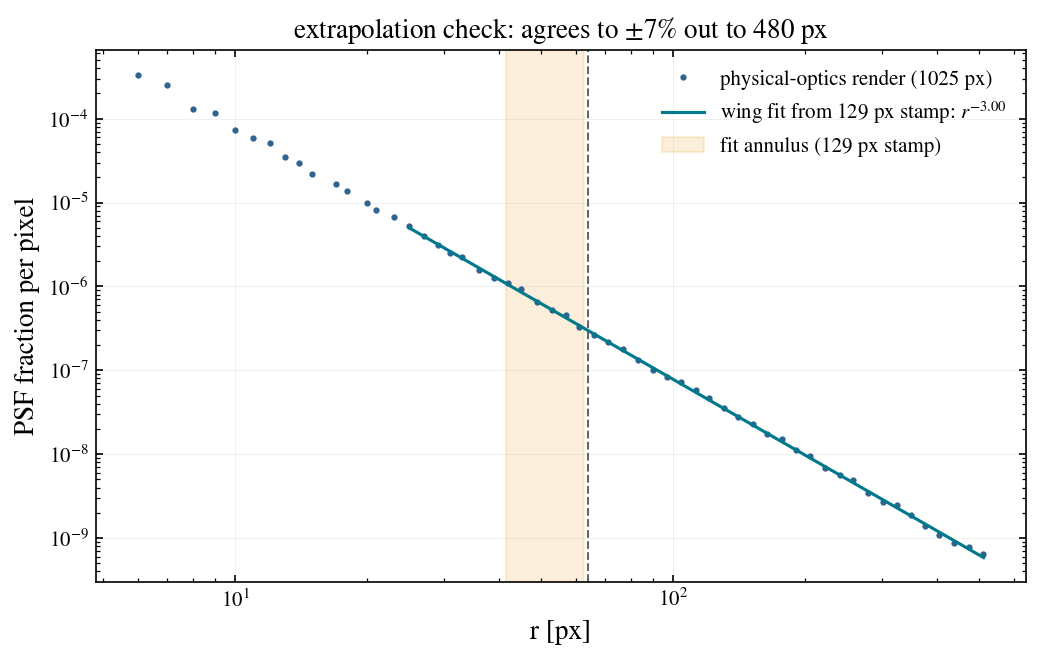

In [14]:
rb = np.unique(np.geomspace(6, hb - 2, 60).astype(int))
prof_big = [np.median(psf_big[(rbig > b - 2) & (rbig < b + 2)]) for b in rb]
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.loglog(rb, prof_big, '.', ms=4, color='#30638e',
          label='physical-optics render (1025 px)')
rr = np.geomspace(25, hb, 100)
ax.loglog(rr, wings[0].profile(rr), '-', color='#00798c', lw=1.5,
          label=f'wing fit from 129 px stamp: $r^{{{wings[0].alpha:.2f}}}$')
ax.axvspan(0.65 * 64, 0.98 * 64, color='#edae49', alpha=0.2,
           label='fit annulus (129 px stamp)')
ax.axvline(64, color='0.4', ls='--', lw=1)
ax.set_xlabel('r [px]'); ax.set_ylabel('PSF fraction per pixel')
ax.set_title('extrapolation check: agrees to $\pm$7% out to 480 px')
ax.legend();

For the **defocused** PSFs the fitted slopes (-3.7, -4.2) are only backed by
the Huygens data out to its ~272 px span; far enough out the wing should
revert to the r^-3 diffraction envelope, so the defocused far wings are
likely slight *underestimates* beyond a few hundred px (small in absolute
terms — their wing amplitudes are ~10x lower to begin with).

The caveat that matters most for the brightest stars: real far halos at
arcminute scales are usually **scatter-dominated** (mirror micro-roughness,
particulates), shallower (~r^-2) and brighter than pure diffraction. The
current wings are therefore a *lower bound* on the far halo — the diffraction
floor. The planned scattered-light PSFs will replace the power-law fit behind
the same `WingModel` interface.

## Summary

- Truncated stamps put a square, ~100-sigma cliff around every bright star;
  with `wings=True` the halo is circular, follows the fitted power law, and
  ends below 0.1 sigma of the noise floor.
- The seam at the old stamp edge is smooth (relative jump at the percent
  level, on a signal that is itself deep in the wing).
- Encircled energy changes by the wing renormalization: **≈0.7%** less flux in
  any core aperture for the in-focus 129 px stamp (≈0.1% for the defocused
  257 px stamps), returned in the halo so the total closes to 100% within 1%.
- Photometry stays magnitude-independent: every star gets the same
  renormalization whether or not its (sub-noise) halo is drawn.
- Wing extent scales as flux^(1/3): ~4 arcsec at G=12, the full detector at
  G=0 — which is physically expected for a 0-mag star.
- The in-focus extrapolation matches an 8x-larger physical-optics render to
  ±7% (and r^-3 is the analytic Airy envelope); the defocused slopes are an
  assumption beyond the ~272 px Huygens data span.
- Scattered-light PSFs are a planned follow-up and will slot in as measured
  `WingModel` profiles; until then the far wings of the brightest stars are
  a lower bound (diffraction only).